<a href="https://colab.research.google.com/github/Lekanggy/MLrepo/blob/main/Neural_Network(Algorithm).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy  as np
import scipy.special
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# neural network class definition
class NeuralNetwork:

  #Initialise the networ
  def __init__(self, inputnodes, hiddennodes, outputnodes, learningrate):
    self.inodes = inputnodes
    self.hnodes = hiddennodes
    self.onodes = outputnodes

    #Learning rates
    self.lr = learningrate

    #Initialise the link weights from , wih(input to hidden), who(hidden to output)
    self.wih = np.random.normal(0.0, pow(self.hnodes, -0.5), (self.hnodes, self.inodes))
    self.who = np.random.normal(0.0, pow(self.onodes, -0.5), (self.onodes, self.hnodes))

    #Define the Activation functions
    self.activation_function = lambda x: scipy.special.expit(x)
    self.inverse_activation_function = lambda x: scipy.special.logit(x)
    pass

  #Train the network
  def train(self, inputs_list, target_list):
    #Convert both into 2D array
    inputs = np.array(inputs_list, ndmin=2).T
    targets = np.array(target_list, ndmin=2).T

    #Calculate the weightds input --->hidden signal,hidden ---> output signal
    hidden_inputs = np.dot(self.wih, inputs)
    hidden_outputs = self.activation_function(hidden_inputs)

    #Calculate the weightds hidden --->final signal, final ---> output_layer signal
    final_inputs = np.dot(self.who, hidden_outputs)
    final_outputs = self.activation_function(final_inputs)

    #Error out
    output_errors = targets - final_outputs

    #errors_hidden = weights.T_(hidden_output) ∙ errors_output
    ## hidden layer error is the output_errors due to input weights, split by weights,
    #recombined at hidden nodes
    hidden_errors = np.dot(self.who.T, output_errors)

    # update the weights for the links between the hidden and output layers
    self.who += self.lr * np.dot((output_errors * final_outputs * (1.0 - final_outputs)), np.transpose(hidden_outputs))

    # update the weights for the links between the input and hidden layers
    self.wih += self.lr * np.dot((hidden_errors * hidden_outputs * (1.0 - hidden_outputs)), np.transpose(inputs))


    pass

  #Query the networrk
  def query(self, inputs_list):

    #Convert the input list to 2D array
    inputs = np.array(inputs_list, ndmin=2).T

    #Calulate signal into input hidden layers
    hidden_inputs = np.dot(self.wih, inputs)

    #Calculate the signal emerging from hidden outpus signals
    hidden_outputs = self.activation_function(hidden_inputs)

    #calculate the signal into final output layer
    final_inputs = np.dot(self.who, hidden_outputs)

    #Calculate the signal emerging from final_outputs layer
    final_outputs = self.activation_function(final_inputs)

    return final_outputs


   # backquery the neural network
    # we'll use the same termnimology to each itemm
  def backquery(self, targets_list):
    # transpose the targets list to a vertical array
    final_outputs = np.array(targets_list, ndmin=2).T

    # calculate the signal into the final output layer
    final_inputs = self.inverse_activation_function(final_outputs)

    # calculate the signal out of the hidden layer
    hidden_outputs = np.dot(self.who.T, final_inputs)
    # scale them back to 0.01 to .99
    hidden_outputs -= np.min(hidden_outputs)
    hidden_outputs /= np.max(hidden_outputs)
    hidden_outputs *= 0.98
    hidden_outputs += 0.01

    # calculate the signal into the hidden layer
    hidden_inputs = self.inverse_activation_function(hidden_outputs)

    # calculate the signal out of the input layer
    inputs = np.dot(self.wih.T, hidden_inputs)
    # scale them back to 0.01 to .99
    inputs -= np.min(inputs)
    inputs /= np.max(inputs)
    inputs *= 0.98
    inputs += 0.01

    return inputs



In [ ]:
#Test the code
input_nodes = 3
hidden_nodes = 3
output_nodes = 3

learning_rate = 0.2

n = NeuralNetwork(input_nodes, hidden_nodes, output_nodes, learning_rate)

In [ ]:
n.query([1.0, 0.5, -1.5])

array([[0.52891569],
       [0.63590106],
       [0.28265655]])

In [ ]:
def open_data(file_path):
  return  open(file_path, "r").readlines()

In [ ]:
train_data = open_data("sample_data/mnist_train_small.csv")
test_data = open_data("sample_data/mnist_test.csv")

In [ ]:
print("Length of Training data: ",len(train_data))
print("Length of test data: ",len(test_data))

Length of Training data:  20000
Length of test data:  10000


In [ ]:
train_data[0]

'6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,67,67,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,131,252,252,66,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,159,250,232,30,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,222,252,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,147,252,183,5,0,0,0,0,0,0,0,20,89,89,73,0,0,0,0,0,0,0,0,0,0,0,0,48,247,252,159,0,0,0,0,0,0,0,79,236,252,252,249,198,16,0,0,0,0,0,0,0,0,0,41,193,252,199,22,0,0,0,0,0,12,135,248,252,252,252,252,252,100,0,0,0,0,0,0,0,0,0,100,252,252,88,0,0,0,0,0,11,171,252,252,235,175,178,252,252,224,0,0,0,0,0,0,0,0,15,209,252,233,12,0,0,0,0,49,177,252,252,89,26,0,2,166,252,252,0,0,0,0,0,0,0,0,96,253,253,59,0,0,0,0,11,177,255,253,92,0,0,0,0,155,253,128,0,0,0,0,0,0,0,0,143,252,252,10,0,0,0,12,171,252,216,110,13,0,0,0,3,180

In [ ]:
test_data[0]

'7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,84,185,159,151,60,36,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,222,254,254,254,254,241,198,198,198,198,198,198,198,198,170,52,0,0,0,0,0,0,0,0,0,0,0,0,67,114,72,114,163,227,254,225,254,254,254,250,229,254,254,140,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,66,14,67,67,67,59,21,236,254,106,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,83,253,209,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,233,255,83,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,129,254,238,44,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,59,249,254,62,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,133,254,187,5,0,

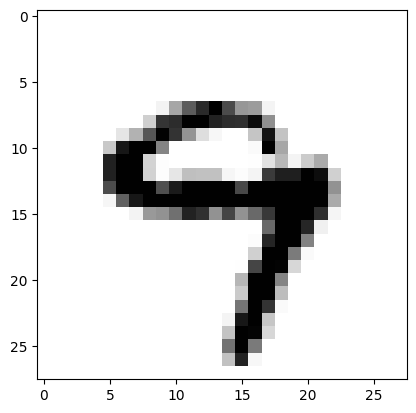

In [ ]:
#Prepare the data for plotlib
all_value = train_data[3].split(",")
img_arr = np.asarray(all_value[1:], dtype="float").reshape((28, 28))
plt.imshow(img_arr, cmap="Greys", interpolation='None')
plt.show()

In [ ]:
scale_input = (np.asarray(all_value[1:], dtype="float")/255 * 0.99) + 0.01
print(scale_input[: 100])

[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01]


In [ ]:
#Predict output
onodes = 10
target_values = np.zeros(onodes) + 0.01
target_values[int(all_value[0])] = 0.99

In [ ]:
print(target_values)

[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.99]


In [ ]:
# number of input, hidden and output nodes
input_nodes = 784
hidden_nodes = 400
output_nodes = 10

# learning rate is 0.3
learning_rate = 0.1
# create instance of neural network
n = NeuralNetwork(input_nodes,hidden_nodes,output_nodes,
learning_rate)

In [ ]:
#Go through all the training records, process and train
epoch = 5

for e in range(epoch):
  print(f"Runing {e + 1} batch....")
  for record in train_data:
    item = record.split(",")
    inputs = ((np.asarray(item[1:], dtype="float")) / 255.0 * 0.99) + 0.01
    targets = np.zeros(output_nodes) + 0.01
    targets[int(item[0])] = 0.99
    n.train(inputs, targets)

    pass

Runing 1 batch....
Runing 2 batch....
Runing 3 batch....
Runing 4 batch....
Runing 5 batch....


In [ ]:
test_item = test_data[0].split(",")
actual = test_item[0]
actual

'7'

In [ ]:
n.query(((np.asarray(test_item[1:], dtype="float")/255.0) * 0.99) + 0.01)

array([[0.00918401],
       [0.00938055],
       [0.01952375],
       [0.03477574],
       [0.00810823],
       [0.00785345],
       [0.019081  ],
       [0.99535577],
       [0.00147531],
       [0.00181521]])

In [ ]:
scorecards = []
for record in test_data:
  all_v = record.split(",")
  correct_label = all_v[0]
  inputs = ((np.asarray(all_v[1:], dtype="float")) / 255.0 * 0.99) + 0.01
  labels = n.query(inputs)
  pred = np.argmax(labels)
  if int(pred) == int(correct_label):
    scorecards.append(1)
  else:
    scorecards.append(0)
  pass

In [ ]:
accuracy = sum(scorecards) / len(scorecards)

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 0.97%


[0.99 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


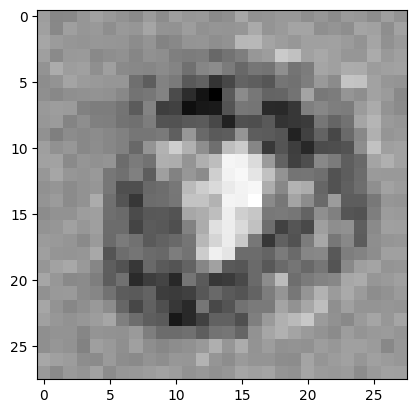

In [ ]:
#Checking the revrese of out of the network by backquering
# run the network backwards, given a label, see what image it produces

# label to test
label = 0
# create the output signals for this label
targets = np.zeros(output_nodes) + 0.01

# all_values[0] is the target label for this record
targets[label] = 0.99
print(targets)

# get image data
image_data = n.backquery(targets)

# plot image data
plt.imshow(image_data.reshape(28,28), cmap='Greys', interpolation='None')